In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

df = pd.read_csv("jan_2014.csv", low_memory=False)

In [2]:
df['WhiteElo'] = pd.to_numeric(df['WhiteElo'], errors='coerce')
df['BlackElo'] = pd.to_numeric(df['BlackElo'], errors='coerce')

df.head(10)
print(df.shape)
#df['WhiteElo'].dtype


(697600, 14)


In [3]:
df['EloDiff'] = abs(df['WhiteElo'] - df['BlackElo'])
df.head()

,GameID,Event,White,Black,Result,Date,Time,WhiteElo,BlackElo,ECO,Opening,TimeControl,Termination,Half Move Count,EloDiff
0,0,Rated Bullet game,claudiomat,MisterBiggStuff,0-1,2013.12.31,23:00:14,1711.0,2035.0,A43,Old Benoni Defense,60+0,Time forfeit,48,324.0
1,1,Rated Bullet game,journal,Kiriush33,1-0,2013.12.31,23:00:20,1691.0,1717.0,C20,King's Pawn Game: Leonardis Variation,60+0,Time forfeit,57,26.0
2,2,Rated Classical game,fuku,AlgeriaCZL,1-0,2013.12.31,23:00:40,1539.0,1205.0,B00,"Nimzowitsch Defense: Scandinavian Variation, A...",900+30,Normal,45,334.0
3,3,Rated Bullet game,miroslavm970,galita,0-1,2013.12.31,23:01:22,1291.0,1262.0,C41,Philidor Defense #3,120+0,Time forfeit,74,29.0
4,4,Rated Blitz game,jr2412,chrisstansell,1-0,2013.12.31,23:00:55,1766.0,1832.0,B57,"Sicilian Defense: Modern Variations, Main Line",180+0,Normal,69,66.0


In [4]:
df['Event'] = df['Event'].str.replace(r'\shttps?://.*', '', regex=True)
print(df['Event'].value_counts())
df['Event'].unique()

Event
Rated Blitz game              260781
Rated Classical game          245985
Rated Bullet game             172843
Rated Bullet tournament         9517
Rated Blitz tournament          5688
Rated Correspondence game       2214
Rated Classical tournament       572
Name: count, dtype: int64


array(['Rated Bullet game', 'Rated Classical game', 'Rated Blitz game',
       'Rated Bullet tournament', 'Rated Correspondence game',
       'Rated Classical tournament', 'Rated Blitz tournament'],
      dtype=object)

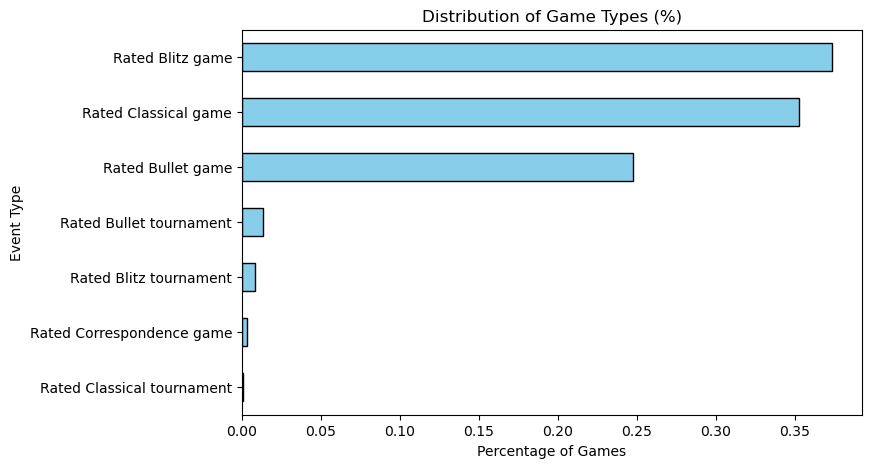

In [5]:
counts = df['Event'].value_counts(normalize=True)

plt.figure(figsize=(8, 5))
counts.sort_values().plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Distribution of Game Types (%)')
plt.xlabel('Percentage of Games')
plt.ylabel('Event Type')
plt.show()

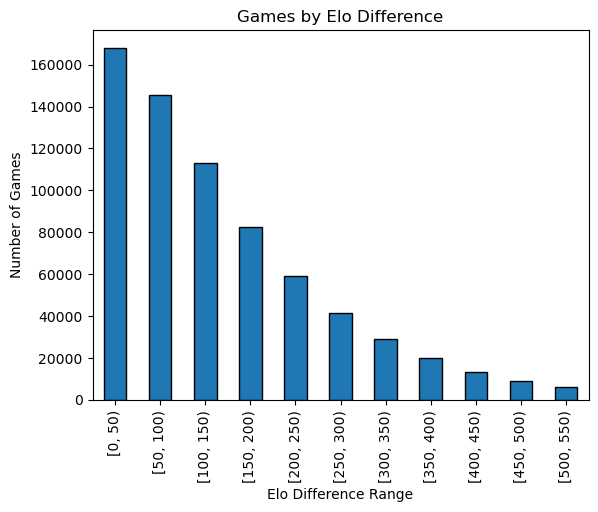

In [6]:
bins = range(0, 551, 50)
df['EloBucket'] = pd.cut(df['EloDiff'], bins=bins, right=False)

counts = df['EloBucket'].value_counts().sort_index()

counts.plot(kind='bar', edgecolor='black')
plt.xlabel('Elo Difference Range')
plt.ylabel('Number of Games')
plt.title('Games by Elo Difference')
plt.show()

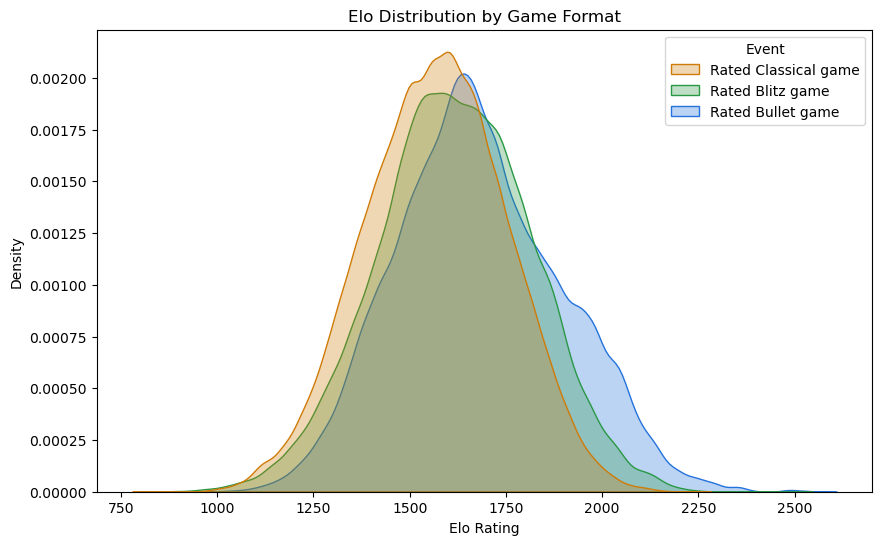

In [7]:
palette = {
    'Rated Classical game': '#cf7b07', # orange
    'Rated Blitz game': '#299845', # green
    'Rated Bullet game': '#2472db' # blue
}

formats = ['Rated Classical game', 'Rated Blitz game', 'Rated Bullet game']
subset = df[df['Event'].isin(formats)].copy()

subset['avgElo'] = (subset['WhiteElo'] + subset['BlackElo']) / 2
plt.figure(figsize=(10,6))
sns.kdeplot(data=subset, x='avgElo', hue='Event', common_norm=False, hue_order=formats, palette=palette, fill=True, alpha=0.3)

plt.title('Elo Distribution by Game Format')
plt.xlabel('Elo Rating')
plt.ylabel('Density')
plt.savefig("elo_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

Event
Rated Blitz game        260781
Rated Classical game    245985
Rated Bullet game       172843
Name: count, dtype: int64


324.0


97.42101490825688
